In [1]:
!pip -q install yfinance pandas matplotlib

In [30]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
symbol = "AAPL"
start_data = "2025-01-01"
end_data = "2025-12-31"

starting_cash = 10000

In [ ]:
# download raw data
raw_data = yf.download(symbol, start=start_data, end=end_data, auto_adjust=True)
# auto_adjust in case stock splits, so no artificial jumps.
"""A market may split e.g. 2 for 1, where 1 share becomes two shares, and the price per share halves.
This makes indivdual stock more affordable, improving liquidity."""

print(raw_data.head())

"""In the data below we see the date. Then the OHLC prices (per stock) that traders deal with. 
OPEN: price at which first trade occurs (when market opens.)
CLOSE: Last trade.
HIGH: highest price of the day.
LOW: lowest price of the day
VOLUME: total numer of shares traded."""

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-01-02  242.525146  247.746623  240.506177  247.577533  55740700
2025-01-03  242.037796  242.853333  240.575781  242.037796  40244100
2025-01-06  243.668915  245.986258  241.878691  242.982661  45045600
2025-01-07  240.894089  244.215939  240.038760  241.659894  40856000
2025-01-08  241.381393  242.385916  238.745797  240.605632  37628900


In [ ]:
price = raw_data[["Close"]] # gets closing data
price = price.squeeze() # converts to single-column data frame into series w/ no title.
price = price.dropna()


In [ ]:
daily_returns = price.pct_change() # price is closing data of each day. Calculates the percentage change between days.
daily_returns = daily_returns.fillna(0) # replace empties w/ 0.


In [ ]:
buy_and_hold = pd.Series(1, index=price.index) # makes a series filled with 1s, with name dates.
#1 means to hold/buy every single day, always in the market. Most basic strategy, so used to compare other strategies.
#Effectively just never selling the stock. Watching what happens to the price.

momentum = (price.diff() > 0).astype(int) # if price goes up, then buy. If price.diff() between days is
#>0, then buy. astype(int) converts True/False to 1/0.


strategies = {
    "HOLD": buy_and_hold,
    "MOM": momentum
}

In [45]:
def equity_curve(signal: pd.Series) -> pd.Series:
    shifted_signal = signal.shift(1).fillna(0) # 1 day later. Cannot use today's signal to trade today.
    # the signal is the 1/0 trade/don't boolean. Also fills any nans.

    daily_growth = 1 + shifted_signal * daily_returns # shifted signal (using whatever strategy) times returns
    # what growth u get if you use said method.
    # if signal 0 (out of market) 1 + 0 * return = 1.0, no change
    # if signal 1 (in market) 1 + 1 * return = ...
    # NB 1+ because of percentage change.

    return daily_growth.cumprod() * starting_cash # compound over time. Multiplies daily growth factors and original stock.

results = {} # dictionary that maps strategy name to equity curve. 

for name, signal in strategies.items(): # simulates every day through the strategies, giving results.
    results[name] = equity_curve(signal) # executes trade method.

print(f"Results for {symbol} from {start_data} to {end_data}:")

trading_years = len(price)/252

for name, curve in results.items():
    final_value = curve.iloc[-1] # gives final value, last place of cash posn.

    cagr = (final_value / starting_cash) ** (1 / trading_years) - 1 # just a formula. aggregate growth.
    # final = starting x rate ^ years. rearrange for rate.

    print(f"{name:<5}: | Final = ${final_value:,.0f} | CAGR = {cagr * 100} %")


Results for AAPL from 2025-01-01 to 2025-12-31:
HOLD : | Final = $11,249 | CAGR = 12.653038204729384 %
MOM  : | Final = $11,090 | CAGR = 11.040432990344007 %


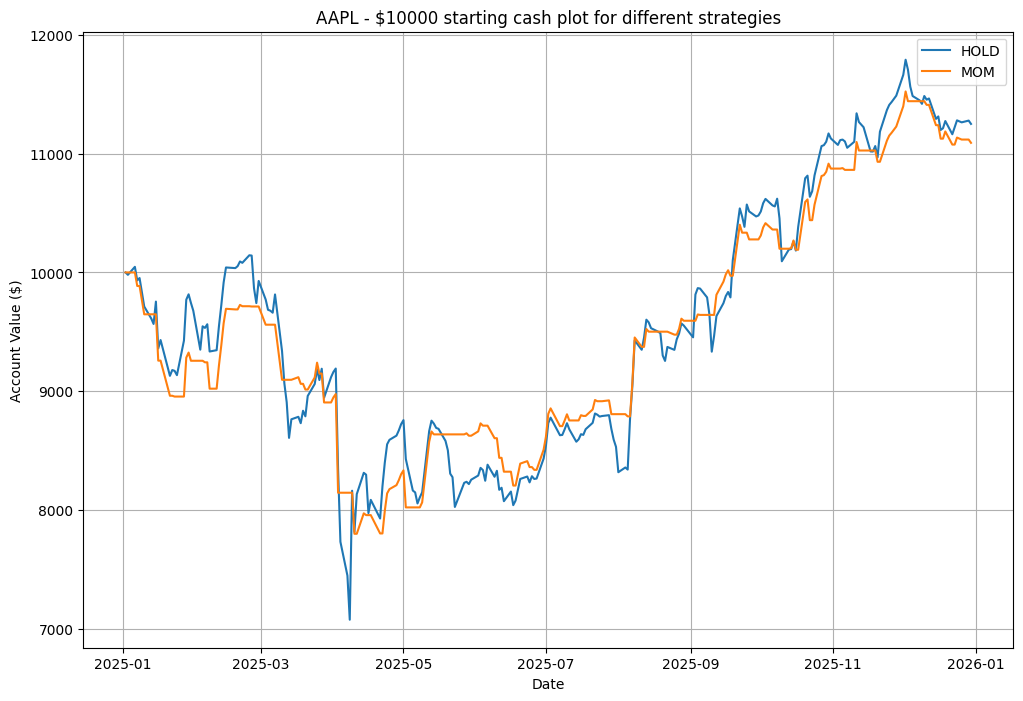

In [42]:
plt.figure(figsize=(12, 8))

for name, curve in results.items():
    plt.plot(curve, label=name)

plt.title(f'{symbol} - ${starting_cash} starting cash plot for different strategies')
plt.xlabel("Date")
plt.ylabel("Account Value ($)")
plt.legend()
plt.grid(True)
plt.show()